# Notebook 3 - ML Curto + Conclusoes

Objetivo:
- Aplicar tecnica simples de ML ao mix de produtos.
- Entregar insights finais para o projeto.

> Atualizado em 2026-05-13 00:51 apos carga de movimentacoes_202605.json.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sqlalchemy import text
from etl_core import obter_engine

plt.style.use('ggplot')
engine = obter_engine()


In [2]:
query = '''
SELECT
    COALESCE(d.descricao, 'SEM_DESCRICAO') AS descricao_produto,
    COALESCE(d.tipo_item_descricao, 'SEM_CATEGORIA') AS categoria,
    SUM(COALESCE(f.qtd_venda, 0)) AS qtd_total,
    SUM(COALESCE(f.valor_total_liquido, 0)) AS faturamento_total,
    AVG(COALESCE(f.valor_total_liquido, 0)) AS ticket_medio_item,
    COUNT(DISTINCT f.data_emissao) AS dias_com_venda
FROM silver.fato_movimentacoes f
LEFT JOIN silver.dim_produtos_servicos d
    ON d.id_produto_servico = f.id_produto_servico
WHERE COALESCE(f.status_item_cancelado, FALSE) = FALSE
GROUP BY 1, 2
HAVING SUM(COALESCE(f.valor_total_liquido, 0)) > 0
'''

df = pd.read_sql_query(text(query), engine)
df.head()


,descricao_produto,categoria,qtd_total,faturamento_total,ticket_medio_item,dias_com_venda
0,Acém Inteiro,Carnes e Pereciveis,12.018,452.523,226.261500,2
1,Acendedor Rápido - 4un/cx,Outros Itens Revenda,7.000,69.220,9.888571,6
2,Água com gás,Bebidas Nao Alcoolicas,61.000,364.900,15.865217,5
3,Água Mineral 350ml c/ gás,Bebidas Nao Alcoolicas,1.000,2.000,2.000000,1
4,Água sem gás,Bebidas Nao Alcoolicas,35.000,203.950,13.596667,6


In [3]:
features = ['qtd_total', 'faturamento_total', 'ticket_medio_item', 'dias_com_venda']
X = df[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

df.groupby('cluster')[features].mean().round(2)


,qtd_total,faturamento_total,ticket_medio_item,dias_com_venda
cluster,,,,
0,8.86,415.01,117.73,3.79
1,195.99,10739.94,148.10,52.11
2,292.82,13984.17,3823.87,3.25
3,56.15,3565.79,296.81,21.59


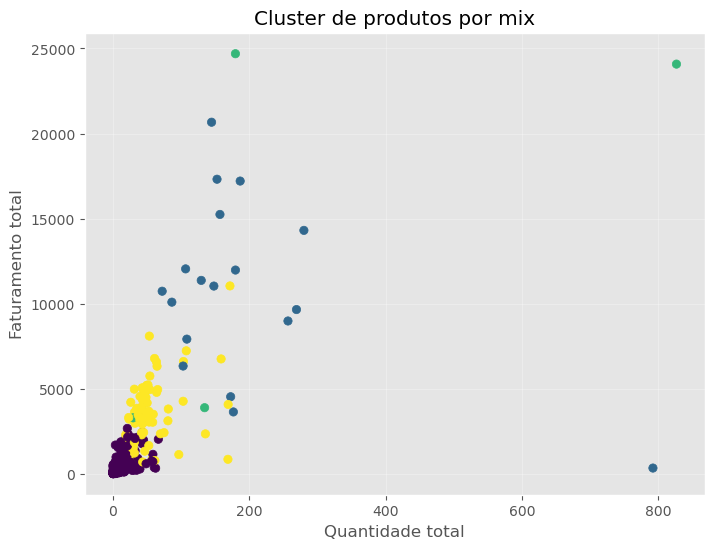

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(df['qtd_total'], df['faturamento_total'], c=df['cluster'])
plt.xlabel('Quantidade total')
plt.ylabel('Faturamento total')
plt.title('Cluster de produtos por mix')
plt.grid(True, alpha=0.3)
plt.show()


## Conclusoes finais

1. Principais categorias do mix (faturamento):
- Carnes Bovinas: R$ 328577.13
- Carnes e Pereciveis: R$ 80146.73
- Outros Itens Revenda: R$ 49890.99
- Bebidas Alcoolicas: R$ 45070.09

2. Produtos de maior impacto financeiro:
- Jantar Parrillero: R$246.90 
- Carcaça Frig. Madu: R$ 24079.44
- Picanha Fazenda Cristal: R$ 20663.96
- Picanha Brasaria: R$ 17312.37
- Assado Tiras FS: R$ 17204.58

3. Padroes encontrados pelo cluster (KMeans, k=4):
- Cluster 2: perfil premium, maior ticket medio R$ 3823.87 e maior faturamento medio por produto R$ 13984.17; 4 produtos.
- Cluster 1: maior recorrencia de venda (media de 52.11 dias com venda), representando itens de giro frequente; 18 produtos.
- Cluster 0: menor faturamento medio por produto R$ 415.01, representando cauda longa; 289 produtos.

4. Recomendacoes operacionais:
- Priorizar disponibilidade dos itens premium e de alta recorrencia para proteger faturamento.
- Usar a segmentacao por cluster para campanhas e metas de margem por grupo de produto.
- Monitorar semanalmente variacao de faturamento por cluster para ajustes rapidos de mix.